# KNN MOTORUNUN ANATOMİSİ

## 1. Aşama: Karşılaştırma (Broadcasting)

**Matematiksel İşlem:**

$$D = X_{train} - q$$

Broadcasting: Tek bir nokta (sorgu noktası), NumPy tarafından eğitim verisinin boyutuna genişletilir ve tüm örneklerle aynı anda karşılaştırılır.

---

## 2. Aşama: Geometrik Uzaklık (L2 Norm)

**Matematiksel İşlem:**

$$d = \sqrt{\sum (x_i - q_i)^2}$$

Farkların kareleri toplanır ve karekök alınarak her örnek ile sorgu noktası arasındaki Öklid uzaklığı bulunur.

---

## 3. Aşama: Sıralama & Kimlik Belirleme (Argsort)

**Kritik Fonksiyon:**

`np.argsort()`

Mesafeler küçükten büyüğe sıralanır. Argsort, mesafelerin sıralı halini değil, sıralı indexlerini döndürür. Bu sayede mesafenin hangi veriye ait olduğu kaybolmaz.

---

## 4. Aşama: Oylama ve Karar (Voting)

**Matematiksel İşlem:**

$$P = \text{argmax}(\text{count}(\text{Labels}))$$

En yakın k komşunun etiketleri sayılır. En çok tekrarlanan sınıf, algoritmanın çıktısı olur. Bu mekanizma çoğunluk oylamasıdır.

## Kütüphaneler, veri, ve verinin ayarlanması

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

Özellikler: ['mean radius' 'mean texture']
Sınıflar: ['malignant' 'benign']


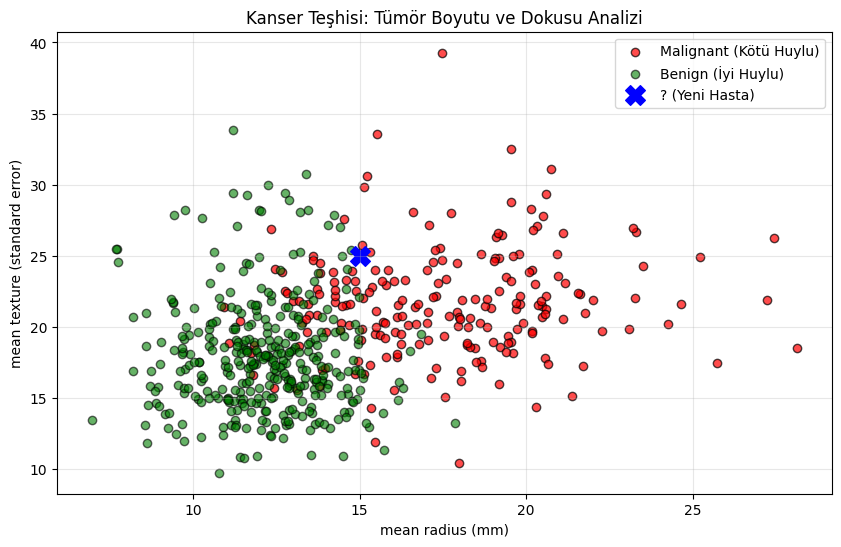

In [ ]:
data = load_breast_cancer()

feature_names = data.feature_names[:2] 
target_names = data.target_names

print(f"Özellikler: {feature_names}")
print(f"Sınıflar: {target_names}")

X = data.data[:, :2] # veri setindeki tüm satırları :, :2 ve ilk 2 sütunu almamızı sağlıyor
y = data.target

plt.figure(figsize=(10, 6))

#1. scatter =  boolean indexing hedef vektörüne indexi 0 olan kanserli hücreleri bulmasını true/false yapıp kanserli hücrelerin kordinatlarını bularak ve kırmızıya boyar
#2. scatter = boolean indexing aynı şekilde bu sefer 1 iyi huylu olanları çekiyoruz ve yeşile boyuyoruz 

plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', alpha=0.7, label='Malignant (Kötü Huylu)', edgecolors='k') 
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='green', alpha=0.6, label='Benign (İyi Huylu)', edgecolors='k')



query_point = np.array([15.0, 25.0]) # verinin ortası yeni hastanın verisi
plt.scatter(query_point[0], query_point[1], color='blue', marker='X', s=200, label='? (Yeni Hasta)')  # mavi çarpı yeni hastayı temsil ediyor

plt.xlabel(f'{feature_names[0]} (mm)')
plt.ylabel(f'{feature_names[1]} (standard error)')
plt.title('Kanser Teşhisi: Tümör Boyutu ve Dokusu Analizi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## KNN motoru

In [ ]:
def knn_predict_manual(X_train, y_train, query_point, k=5):
    # tüm hastalardan gelen yeni hastanın verisini çıkarıyor  
    # Broadcasting = tek değeri (query_point) sanal olarak çoğaltıp X_train nin boyutu ile eşitler ve ardından çıkarma işlemi yapılır
    diferences = X_train - query_point

    # bulunan farkların karesi alınır (negatif değerleri pozitife çevirmek için) böylece uzaklık hesaplanabilir
    squared_differences = diferences ** 2

    # kordinat farklarının kareleri axis = 1 boyunca toplanır yani satırları böylece her hasta için tek sayı elde ederiz
    sum_squared = np.sum(squared_differences, axis=1)

    # gerçek uzaklığı bulmak için sqrt ile karesel uzaklığı buluyoruz
    distances = np.sqrt(sum_squared)

    # mesafeler küçükten büyüğe sıralanıyor argsort kullanımının sebebi kimliklerin(indexlerin) kaybolmaması
    sorted_indices = np.argsort(distances)

    # listeyi kesiyoruz böylece k tane en yakın komşuyu alıyoruz
    nearest_indices = sorted_indices[:k]

    # indexler ile y_train kontrolü sağlıyoruz
    nearest_labels = y_train[nearest_indices]

    # oyları sıralıyoruz
    counts = np.bincount(nearest_labels)

    # en büyük sayının indexini alıyoruz
    prediction = np.argmax(counts)

    # sonuçları dödürüyoruz
    return prediction, nearest_labels, nearest_indices

# Test ve Sonuçlar


--- KNN Sonuç Raporu (K = 5) ---
Sorgu Noktasi Kordinatlari: [15. 25.]
En Yakin 5 Komsunun Kararlari: [0 0 1 1 0]
Oylama Sonucu: Malignant (Kötü Huylu)


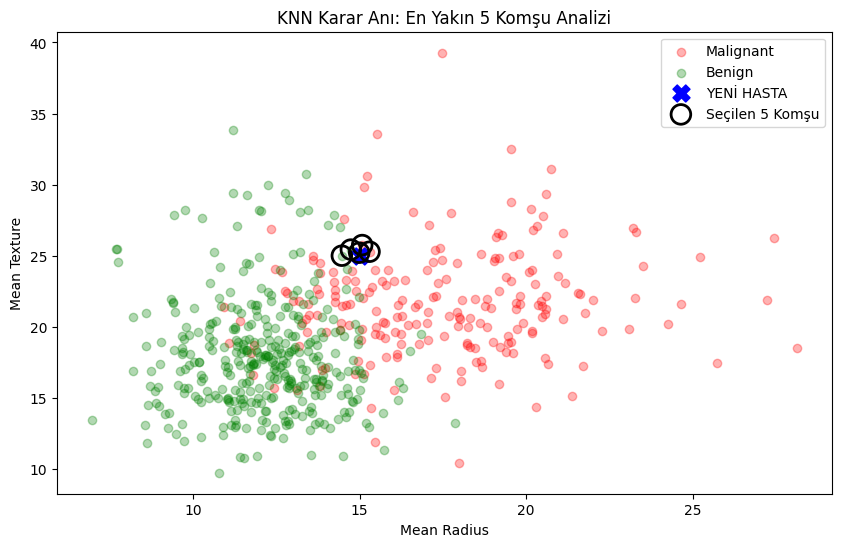

In [7]:
K_VALUE = 5

tahmin, komsularin_oylari, komsu_indeksleri = knn_predict_manual(X, y, query_point, k=K_VALUE)

sinif_isimleri = {0: "Malignant (Kötü Huylu)", 1: "Benign (İyi Huylu)"}

print(f"\n--- KNN Sonuç Raporu (K = {K_VALUE}) ---")
print(f"Sorgu Noktasi Kordinatlari: {query_point}")
print(f"En Yakin {K_VALUE} Komsunun Kararlari: {komsularin_oylari}")
print(f"Oylama Sonucu: {sinif_isimleri[tahmin]}")

plt.figure(figsize=(10, 6))
 
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', alpha=0.3, label='Malignant')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='green', alpha=0.3, label='Benign')
 
plt.scatter(query_point[0], query_point[1], color='blue', marker='X', s=150, label='YENİ HASTA')

 
selected_neighbors = X[komsu_indeksleri]
plt.scatter(selected_neighbors[:, 0], selected_neighbors[:, 1], 
            facecolors='none', edgecolors='black', s=200, linewidth=2, label=f'Seçilen {K_VALUE} Komşu')

plt.title(f'KNN Karar Anı: En Yakın {K_VALUE} Komşu Analizi')
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.legend()
plt.show()